In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
windows = pd.read_csv("data/windows_4192026.csv")
wsl = pd.read_csv("data/wsl_4192026.csv")
hydra = pd.read_csv("data/hydra0_4192026.csv")
ubuntu = pd.read_csv("data/ubuntu_4192026.csv")

windows["time"] = windows["time"] * 1_000_000
wsl["time"] = wsl["time"] * 1_000_000
hydra["time"] = hydra["time"] * 1_000_000
ubuntu["time"] = ubuntu["time"] * 1_000_000

print(windows.head())
print(wsl.head())
print(hydra.head())
print(ubuntu.head())

   n     time
0  3  1066.95
1  4   699.38
2  5   696.24
3  6   695.72
4  7   699.31
   n      time
0  3  644.4229
1  4  242.3316
2  5  227.4193
3  6  208.1611
4  7  243.7394
   n       time
0  3  90.824813
1  4  79.736114
2  5  77.704899
3  6  78.381412
4  7  77.845901
   n      time
0  3  428.7013
1  4  153.0742
2  5  145.2378
3  6  129.1949
4  7  125.0532


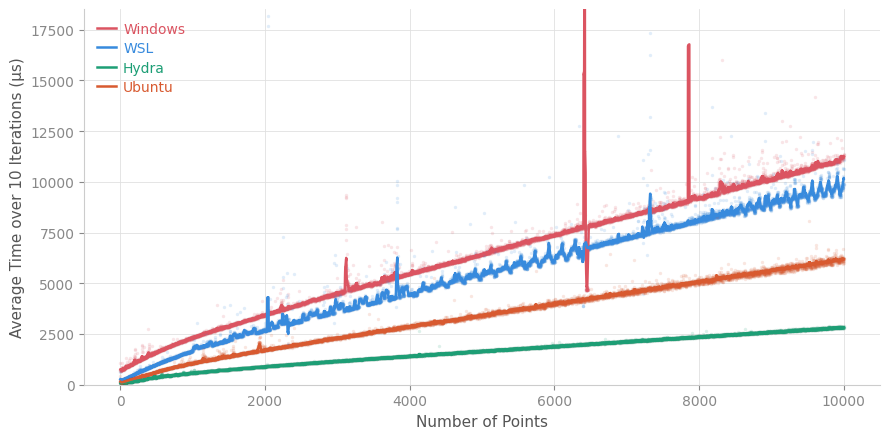

In [25]:
COLORS = {"Windows": "#DB5461", "WSL": "#378ADD", "Hydra": "#1D9E75", "Ubuntu": "#D85A30"}

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

datasets = {"Windows": windows, "WSL": wsl, "Hydra": hydra, "Ubuntu": ubuntu}

for label, df in datasets.items():
    color = COLORS[label]
    sorted_df = df.sort_values("n")
    smoothed = (
        sorted_df.set_index("n")["time"]
        .rolling(window=20, center=True, min_periods=1)
        .mean()
    )

    # Faint raw scatter
    ax.scatter(
        sorted_df["n"], sorted_df["time"],
        alpha=0.15, s=6, color=color, zorder=2, linewidths=0,
    )
    # Bold smoothed line
    ax.plot(
        smoothed.index, smoothed.values,
        linewidth=1.8, color=color, label=label, zorder=3,
    )

# Grid
ax.set_axisbelow(True)
ax.grid(axis="y", color="#e0e0e0", linewidth=0.6)
ax.grid(axis="x", color="#e0e0e0", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")

ax.set_xlabel("Number of Points", fontsize=11, color="#555")
ax.set_ylabel("Average Time over 10 Iterations (μs)", fontsize=11, color="#555")
ax.tick_params(colors="#888", labelsize=10)

# Show 99th percentile
ax.set_ylim(0, df["time"].quantile(0.99) * 3)

legend = ax.legend(
    frameon=False, fontsize=10,
    handlelength=1.4, handletextpad=0.5, labelspacing=0.4,
    labelcolor="linecolor",
)

plt.tight_layout()
plt.savefig("graph.png", dpi=600, bbox_inches="tight")